In [2]:
import numpy as np
import sspspace
import matplotlib.pyplot as plt
import nengo

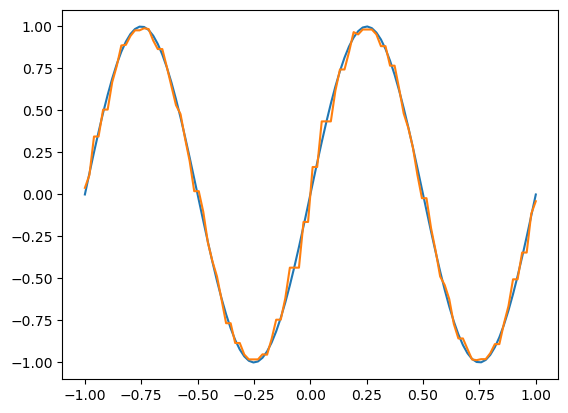

In [112]:
ssp_dim = 128
k = 8

space = sspspace.RandomSSPSpace(domain_dim=1, ssp_dim=ssp_dim, length_scale=0.2)
domain = np.linspace(-1, 1, 100)
domain_ssp = space.encode(domain[:,None])

def hash(x):
    v = np.packbits(x>0, bitorder='little')
    return int.from_bytes(v.tobytes(), byteorder='little')

def encode(x, k):
    assert len(x)%k == 0
    result = []
    for i in range(0,len(x), k):
        index = hash(x[i:i+k]>0)
        result.append(np.eye(2**k)[index])
    return np.concatenate(result)

a = np.array([encode(xx, k=k) for xx in domain_ssp])
target = np.sin(2*np.pi*domain)

dec, info = nengo.solvers.LstsqL2()(a, target)
y_hat = np.dot(a, dec)

plt.plot(domain, target)
plt.plot(domain, y_hat)

plt.show()

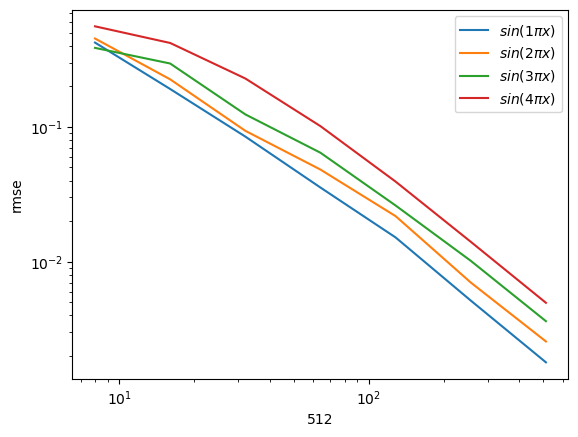

In [104]:
Ds = [8, 16, 32, 64, 128, 256, 512]
k = 2
length_scale = 0.1
S = 5

freqs = [1,2,3,4]

for f in freqs:
    rmses = []
    for D in Ds:
        rmse = []
        for seed in range(S):
            space = sspspace.RandomSSPSpace(domain_dim=1, ssp_dim=D, length_scale=length_scale, rng=np.random.RandomState(seed=seed))
            domain = np.linspace(-1, 1, 100)
            domain_ssp = space.encode(domain[:,None])
            a = np.array([encode(xx, k=k) for xx in domain_ssp])

            
            target = np.sin(np.pi*f*domain)
            
            
            dec, info = nengo.solvers.LstsqL2(reg=1e-1)(a, target)
            rmse.append(np.mean(info['rmses']))
        rmses.append(np.mean(rmse))
    plt.loglog(Ds, rmses, label=f'$sin({f} \\pi x)$') 
plt.legend()
plt.xlabel(D)
plt.ylabel('rmse')
plt.show()



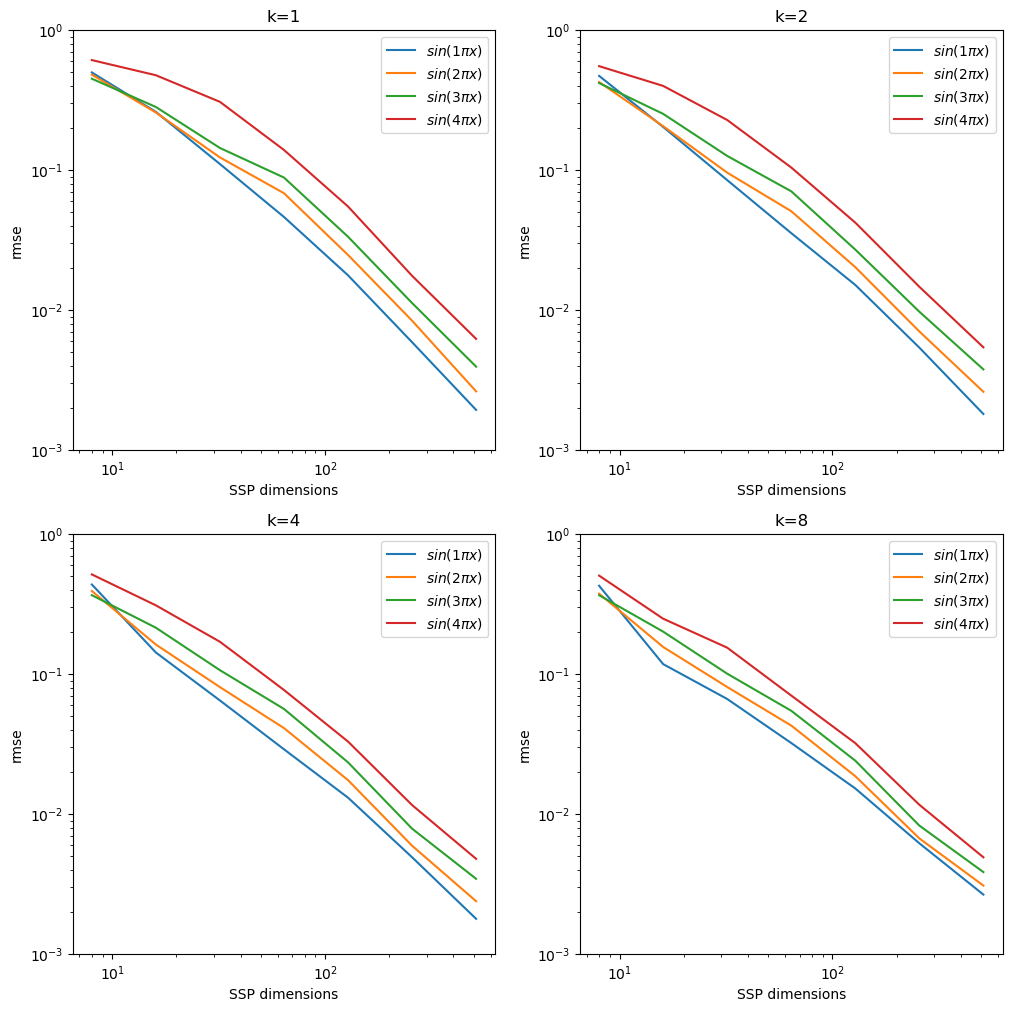

In [109]:
Ds = [8, 16, 32, 64, 128, 256, 512]
length_scale = 0.1
S = 10

ks = [1,2,4,8]
freqs = [1,2,3,4]

plt.figure(figsize=(12,12))
for z,k in enumerate(ks):
    plt.subplot(2,2,z+1)
    
    for f in freqs:
        rmses = []
        for D in Ds:
            rmse = []
            for seed in range(S):
                space = sspspace.RandomSSPSpace(domain_dim=1, ssp_dim=D, length_scale=length_scale, rng=np.random.RandomState(seed=seed))
                domain = np.linspace(-1, 1, 100)
                domain_ssp = space.encode(domain[:,None])
                a = np.array([encode(xx, k=k) for xx in domain_ssp])
    
                
                target = np.sin(np.pi*f*domain)
                
                
                dec, info = nengo.solvers.LstsqL2(reg=1e-1)(a, target)
                rmse.append(np.mean(info['rmses']))
            rmses.append(np.mean(rmse))
        plt.loglog(Ds, rmses, label=f'$sin({f} \\pi x)$') 
    plt.legend()
    plt.xlabel('SSP dimensions')
    plt.ylabel('rmse')
    plt.title(f'k={k}')
    plt.ylim(1e-3,1e-0)
plt.show()

